In [1]:
import jax
import jax.numpy as jnp
import diffrax as dfx
import equinox as eqx
import json

import matplotlib.pyplot as plt

from models import HamiltonianNN, NeuralODE
from vector_fields import vector_field_three_body_plummer, vector_field_three_body_repulsive, vector_field_hnn_potenergy, vector_field_hnn_totenergy, vector_field_node_vanilla, vector_field_node_phys
from utilities import Params, integrate_vector_field, to_canonical, split_train_val, save_model, load_model
from train import train_partially_observed, train_fully_observed

In [2]:
seed = 0
key = jax.random.PRNGKey(seed)

In [3]:
def zero_total_momentum(v, masses):
    """
    v: array (..., n_bodies, dim) velocities
    masses: array (n_bodies,)
    returns v' with sum_i m_i v'_i = 0
    """
    M = jnp.sum(masses)
    V_cm = jnp.tensordot(masses, v, axes=(0, -2)) / M   # (..., dim)
    return v - V_cm[... , None, :] 

In [4]:
def sample_ic_batch(key: jax.random.PRNGKey, system_params: Params, N: int):
    """
    Samples initial conditions for the 3D triangular 3-mass system.

    Returns shape (N, 18):
    [x0, y0, z0, x1, y1, z1, x2, y2, z2,
     vx0, vy0, vz0, vx1, vy1, vz1, vx2, vy2, vz2]
    """
    masses = jnp.array([system_params.m0, system_params.m1, system_params.m2])

    # Split keys
    key0, key1, key2, key3, keyz = jax.random.split(key, 5)

    # --- Base triangular layout (roughly upright triangle in x–y) ---

    # Mass 0 near top
    x0 = jax.random.uniform(key0, (N,), minval=0.3, maxval=0.7)
    y0 = jax.random.uniform(key0, (N,), minval=1.0, maxval=1.4)

    # Mass 1 bottom-left region
    x1 = jax.random.uniform(key1, (N,), minval=0.1, maxval=0.4)
    y1 = jax.random.uniform(key1, (N,), minval=0.1, maxval=0.5)

    # Mass 2 bottom-right region
    x2 = jax.random.uniform(key2, (N,), minval=0.6, maxval=0.9)
    y2 = jax.random.uniform(key2, (N,), minval=0.1, maxval=0.5)

    # z-coordinates: small perturbations around 0 (near a plane)
    z0 = jax.random.uniform(keyz, (N,), minval=-0.5, maxval=0.5)
    z1 = jax.random.uniform(keyz, (N,), minval=-0.5, maxval=0.5)
    z2 = jax.random.uniform(keyz, (N,), minval=-0.5, maxval=0.5)

    # Stack positions: (N, 9)
    r = jnp.stack([x0, y0, z0,
                   x1, y1, z1,
                   x2, y2, z2], axis=-1)

    # Recenter center of mass to origin
    r_reshaped = r.reshape(N, 3, 3)               # (N, n_bodies, dim)
    total_mass = jnp.sum(masses)
    r_cm = (masses[None, :, None] * r_reshaped).sum(axis=1, keepdims=True) / total_mass
    r_reshaped = r_reshaped - r_cm                # shift COM to origin
    r = r_reshaped.reshape(N, 9)

    # Zero total momentum
    v = jax.random.uniform(key3, (N, 9), minval=-0.3, maxval=0.3)
    v_reshaped = v.reshape(N, 3, 3)
    v_zero = jax.vmap(zero_total_momentum, in_axes=(0, None))(v_reshaped, masses)
    v = v_zero.reshape(N, 9)

    # Return concatenated state: (N, 18)
    return jnp.concatenate([r, v], axis=-1)

In [5]:
system_params = Params(m0=1.0, m1=1.0, m2=1.0, G=1.0)
trajectory_length = 1.0
trajectory_steps = 1001
n_trajectories = 4000
eps=1e-1

ts = jnp.linspace(0.0, trajectory_length, trajectory_steps)

y0s = sample_ic_batch(key, system_params, n_trajectories)

solve_batch = integrate_vector_field(ts=ts, term=vector_field_three_body_plummer, eps=eps)
ys_all = solve_batch(model=None, params=system_params, y0s=y0s)   # (N, T, 6)
print("ys_all:", ys_all.shape)


# plt.figure()
# for i in range(ys_all.shape[0]):
#     plt.plot(ts, ys_all[i, :, 0], alpha=0.3, color='black', lw=0.3)  # x0
# plt.title('Position of mass 0 over time for 2000 samples')
# plt.xlabel('Time')
# plt.ylabel('Position x0')
# plt.show()

ys_all: (4000, 1001, 18)


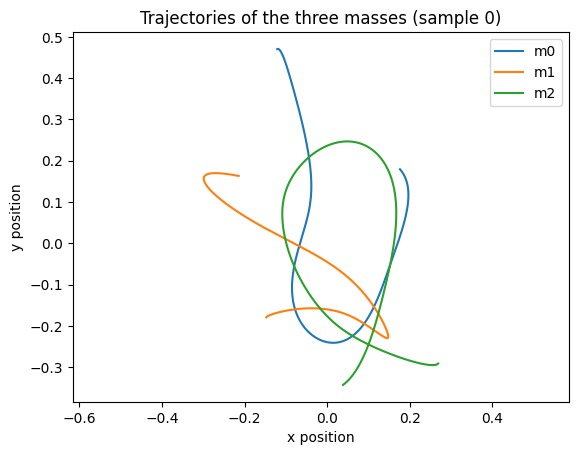

In [6]:
plt.plot(ys_all[3, :, 0], ys_all[3, :, 1], label='m0')
plt.plot(ys_all[3, :, 3], ys_all[3, :, 4], label='m1')
plt.plot(ys_all[3, :, 6], ys_all[3, :, 7], label='m2')
plt.title('Trajectories of the three masses (sample 0)')
plt.xlabel('x position')
plt.ylabel('y position')
plt.legend()
plt.axis('equal')
plt.show()

### Initialize neural networks

In [8]:
hidden_dim = 128
depth = 4
relative_distances = True

In [9]:
key, subkey = jax.random.split(key)
hnn_potenergy = HamiltonianNN(key=subkey, input_dim=9, hidden_dim=hidden_dim, depth=depth, relative_distances=relative_distances)
hnn_potenergy_params, hnn_potenergy_static = eqx.partition(hnn_potenergy, eqx.is_array)

# key, subkey = jax.random.split(key)
# hnn_totenergy = HamiltonianNN(key=subkey, input_dim=18, hidden_dim=hidden_dim, relative_distances=relative_distances)
# hnn_totenergy_params, hnn_totenergy_static = eqx.partition(hnn_totenergy, eqx.is_array)

# key, subkey = jax.random.split(key)
# node = NeuralODE(key=subkey, input_dim=18, hidden_dim=64, output_dim=9, relative_distances=True)
# node_params, node_static = eqx.partition(node, eqx.is_array)

In [10]:
ys_can = to_canonical(ys_all, system_params.m0, system_params.m1, system_params.m2)

train_fraction = 0.85

key, subkey = jax.random.split(key)
train_all, val_all = split_train_val(subkey, ys_can, train_fraction)

### Train HNN model 1 (learning potential energy)

In [11]:
system_params

Params(m0=1.0, m1=1.0, m2=1.0, G=1.0)

In [12]:
batch_size = 64
epochs = 300
learning_rate = 1e-3
lr_schedule={
    'type': 'exponential_decay',
    'decay_rate': 0.95,     
    'decay_epochs': 10     
}

In [13]:
run_hnn_potenergy = integrate_vector_field(ts, term=vector_field_hnn_potenergy, eps=eps)
hnn_potenergy_params, hnn_potenergy_static, losses = train_partially_observed(
    batch_size=batch_size, 
    epochs=epochs, 
    key=subkey, 
    run_hnn=run_hnn_potenergy, 
    system_params=system_params, 
    model_params=hnn_potenergy_params, 
    model_static=hnn_potenergy_static, 
    train_all=train_all, 
    val_all=val_all, 
    learning_rate=learning_rate,
    lr_schedule=lr_schedule
)

LR schedule: exponential_decay, decay=0.95 every 10 epochs
Epoch    1/300 | Train Loss: 0.225858 | Val Loss: 0.229564 | LR: 1.00e-03
Epoch   25/300 | Train Loss: 0.140385 | Val Loss: 0.145567 | LR: 9.03e-04
Epoch   50/300 | Train Loss: 0.122084 | Val Loss: 0.137812 | LR: 7.74e-04
Epoch   75/300 | Train Loss: 0.146193 | Val Loss: 0.137178 | LR: 6.98e-04
Epoch  100/300 | Train Loss: 0.121026 | Val Loss: 0.139721 | LR: 5.99e-04
Epoch  125/300 | Train Loss: 0.110701 | Val Loss: 0.132570 | LR: 5.40e-04
Epoch  150/300 | Train Loss: 0.104966 | Val Loss: 0.132697 | LR: 4.63e-04
Epoch  175/300 | Train Loss: 0.106226 | Val Loss: 0.128076 | LR: 4.18e-04
Epoch  200/300 | Train Loss: 0.117236 | Val Loss: 0.130877 | LR: 3.58e-04
Epoch  225/300 | Train Loss: 0.113252 | Val Loss: 0.130612 | LR: 3.24e-04
Epoch  250/300 | Train Loss: 0.132198 | Val Loss: 0.129098 | LR: 2.77e-04
Epoch  275/300 | Train Loss: 0.154961 | Val Loss: 0.129336 | LR: 2.50e-04
Epoch  300/300 | Train Loss: 0.127911 | Val Loss: 0.1

In [13]:
# run_hnn_totenergy = integrate_vector_field(ts, term=vector_field_hnn_totenergy)
# hnn_totenergy_params, hnn_totenergy_static = train_partially_observed(
#     batch_size=64, 
#     epochs=300, 
#     key=subkey, 
#     run_hnn=run_hnn_totenergy, 
#     system_params=system_params, 
#     model_params=hnn_totenergy_params, 
#     model_static=hnn_totenergy_static, 
#     train_all=train_all, 
#     val_all=val_all, 
#     learning_rate=1e-3,
#     lr_schedule={
#         'type': 'step_decay',
#         'decay_rate': 0.5,      # Halve the LR
#         'decay_epochs': 100     # Every 100 epochs
#     }
# )

In [14]:
# run_node = integrate_vector_field(ts, term=vector_field_node)
# node_params, node_static = train_partially_observed(
#     batch_size=64,
#     epochs=400, 
#     key=subkey, 
#     run_hnn=run_node, 
#     system_params=system_params, 
#     model_params=node_params, 
#     model_static=node_static, 
#     train_all=train_all, 
#     val_all=val_all, 
#     learning_rate=1e-3,
#         lr_schedule={
#         'type': 'step_decay',
#         'decay_rate': 0.5,      # Halve the LR
#         'decay_epochs': 100     # Every 100 epochs
#     }
# )

### Save models

In [14]:
save_dir = f"checkpoints/epsilon_range_test/eps_{eps:.1f}".replace(".", "-") + "/"

In [15]:
# Save metadata
metadata = {
    "model_type": 'hnn',
    "epochs": epochs,
    "batch_size": batch_size,
    "learning_rate": learning_rate,
    "lr_schedule": lr_schedule,
    "hidden_dim": hidden_dim,
    "depth": depth,
    "relative_distances": relative_distances,
    "system_params": {
        "m0": float(system_params.m0),
        "m1": float(system_params.m1),
        "m2": float(system_params.m2),
        "G": float(system_params.G),
    },
    "n_trajectories": n_trajectories,
    "trajectory_length": trajectory_length,
    "trajectory_steps": trajectory_steps,
    "train_fraction": train_fraction,
    "seed": seed,
}

In [16]:
import json
metadata_path = save_dir + "metadata.json"
with open(metadata_path, "w") as f:
        json.dump(metadata, f, indent=2)

FileNotFoundError: [Errno 2] No such file or directory: 'checkpoints/epsilon_range_test/eps_0-1/metadata.json'

In [ ]:
# import yaml
# import os
# from pathlib import Path

# config_path = Path(os.path.join(save_dir, "config.yaml"))
# with config_path.open("w") as f:
#     yaml.safe_dump(metadata, f, sort_keys=False)

In [ ]:
hnn_model_final_potenergy   = eqx.combine(hnn_potenergy_params, hnn_potenergy_static) #hnn_model_pot
#hnn_model_final_totenergy = eqx.combine(hnn_totenergy_params, hnn_totenergy_static) #hnn_model_tot
#node_model_final  = eqx.combine(node_params, node_static) #node_model
# # ##
save_model("hnn_potenergy_three_body", save_dir, hnn_model_final_potenergy, aux={"system_params": system_params})
#save_model("hnn_totenergy_three_body_rel_distance_300ep_lr_decay", "checkpoints/radius_1-0/absolute_positions/2025-11-25", hnn_model_final_totenergy, aux={"system_params": system_params})
#save_model("node_triangular_mass_spring_abs_pos_400ep_lr_decay", "checkpoints/spring_constant_0-05/absolute_positions/2025-11-20", node_model_final, aux={"system_params": system_params})

### Load model from checkpoints

In [20]:
eps=1e-0
system_params = Params(m0=1.0, m1=1.0, m2=1.0, G=1.0)

In [21]:
model_like_hnn_pot = HamiltonianNN(input_dim=9, hidden_dim=128, key=jax.random.PRNGKey(0), relative_distances=True)
system_params_like = system_params

model_name_hnn_pot = "hnn_potenergy_three_body_rel_distance_200ep_lr_decay_larger_z_range"
hnn_pot_checkpoint_dir = "checkpoints/plummersoftening/eps_1-0/radius_1-0/relative_distances/2025-12-03"
aux_like = {"system_params": system_params_like}

hnn_model_pot, aux_loaded_pot = load_model(
    model_name = model_name_hnn_pot,
    ckpt_dir = hnn_pot_checkpoint_dir,
    model_like = model_like_hnn_pot,
    aux_like = aux_like,
)

In [22]:
# model_like_hnn_tot = HamiltonianNN(input_dim=18, key=jax.random.PRNGKey(0), depth=3, relative_distances=False)
# system_params_like =  Params(m0=1.0, m1=1.2, m2=1.0, G=1.0)

# model_name_hnn_tot = "hnn_totenergy_three_body_abs_pos_300ep_lr_decay"
# hnn_tot_checkpoint_dir = "checkpoints/radius_1-0/absolute_positions/2025-11-25"
# aux_like = {"system_params": system_params_like}

# hnn_model_tot, aux_loaded_tot = load_model(
#     model_name = model_name_hnn_tot,
#     ckpt_dir = hnn_tot_checkpoint_dir,
#     model_like = model_like_hnn_tot,
#     aux_like = aux_like,
# )

In [ ]:
# model_like_node = NeuralODE(input_dim=18, output_dim=9, key=jax.random.PRNGKey(0), depth=3, relative_distances=False)
# system_params_like = Params(m0=1.0, m1=1.0, m2=1.0, k01=0, k12=0, k02=0, L01=0.9, L12=0.9, L02=0.9)

# model_name_node = "node_triangular_mass_spring_abs_pos_400ep_lr_decay"
# node_checkpoint_dir = "checkpoints/spring_constant_0-05/absolute_positions/2025-11-20"
# aux_like = {"system_params": system_params_like}

# node_model, aux_loaded_node = load_model(
#     model_name = model_name_node,
#     ckpt_dir = node_checkpoint_dir,
#     model_like = model_like_node,
#     aux_like = aux_like,
# )

In [ ]:
# model_like_hnn_tot_abs = HamiltonianNN(input_dim=18, key=jax.random.PRNGKey(0), depth=3, relative_distances=False)
# system_params_like =  Params(m0=1.0, m1=1.2, m2=1.0, k01=0, k12=0, k02=0, L01=0.9, L12=0.9, L02=0.9)

# model_name_hnn_tot_abs = "hnn_totenergy_triangular_mass_spring_abs_pos_400ep_lr_decay"
# hnn_tot_checkpoint_dir_abs = "checkpoints/spring_constant_0-05/absolute_positions/2025-11-20"
# aux_like = {"system_params": system_params_like}

# hnn_model_tot_abs, aux_loaded_tot_abs = load_model(
#     model_name = model_name_hnn_tot_abs,
#     ckpt_dir = hnn_tot_checkpoint_dir_abs,
#     model_like = model_like_hnn_tot_abs,
#     aux_like = aux_like,
# )

In [ ]:
# ----- make a long grid (same dt) -----

def make_long_ts(ts, factor=10):
    ts = jnp.asarray(ts)
    t0 = float(ts[0]); dt = float(ts[1]-ts[0]); T = float(ts[-1]-ts[0])
    t1 = t0 + factor*T
    n = int(round((t1 - t0)/dt)) + 1
    return jnp.linspace(t0, t1, n)

ts_long = make_long_ts(ts, factor=20)   # e.g., 20x longer


# HNN long integrator
def make_hnn_pot_long(ts_long):
    ts_host = jnp.asarray(ts_long)
    t0 = float(ts_host[0]); t1 = float(ts_host[-1])
    term = dfx.ODETerm(vector_field_hnn_potenergy)
    solver = dfx.Tsit5()
    saveat = dfx.SaveAt(ts=ts_host)
    ctrl = dfx.PIDController(rtol=1e-6, atol=1e-8)
    def run(model, params, y0s_full):
        def solve_one(y0):
            sol = dfx.diffeqsolve(term, solver, t0=t0, t1=t1, dt0=None,
                                  y0=y0, args=(model, params, eps),
                                  saveat=saveat, stepsize_controller=ctrl)
            return sol.ys
        return jax.vmap(solve_one)(y0s_full)
    return run

def make_hnn_tot_long(ts_long):
    ts_host = jnp.asarray(ts_long)
    t0 = float(ts_host[0]); t1 = float(ts_host[-1])
    term = dfx.ODETerm(vector_field_hnn_totenergy)
    solver = dfx.Tsit5()
    saveat = dfx.SaveAt(ts=ts_host)
    ctrl = dfx.PIDController(rtol=1e-6, atol=1e-8)
    def run(model, masses, y0s_full):
        def solve_one(y0):
            sol = dfx.diffeqsolve(term, solver, t0=t0, t1=t1, dt0=None,
                                  y0=y0, args=(model, masses),
                                  saveat=saveat, stepsize_controller=ctrl)
            return sol.ys
        return jax.vmap(solve_one)(y0s_full)
    return run

# # NODE long integrator
def make_node_long(ts_long):
    ts_host = jnp.asarray(ts_long)
    t0 = float(ts_host[0]); t1 = float(ts_host[-1])
    term = dfx.ODETerm(vector_field_node)
    solver = dfx.Tsit5()
    saveat = dfx.SaveAt(ts=ts_host)
    ctrl = dfx.PIDController(rtol=1e-6, atol=1e-8)
    def run(model, params, y0s_full):
        def solve_one(y0):
            sol = dfx.diffeqsolve(term, solver, t0=t0, t1=t1, dt0=None,
                                  y0=y0, args=(model, params),
                                  saveat=saveat, stepsize_controller=ctrl)
            return sol.ys
        return jax.vmap(solve_one)(y0s_full)
    return run

def make_truth_long(ts_long, params, max_steps=16384, rtol=1e-6, atol=1e-8):
    ts_host = jnp.asarray(ts_long)
    t0 = float(ts_host[0]); t1 = float(ts_host[-1])
    term = dfx.ODETerm(vector_field_three_body_plummer)
    solver = dfx.Tsit5()
    saveat = dfx.SaveAt(ts=ts_host)
    ctrl = dfx.PIDController(rtol=rtol, atol=atol)
    def run(y0s_full):
        def to_vel_state(y0_can):
            (qx0,qy0,qz0,
             qx1,qy1,qz1,
             qx2,qy2,qz2,
             px0,py0,pz0,
             px1,py1,pz1,
             px2,py2,pz2) = y0_can
            
            # velocities v = p / m
            vx0, vy0, vz0 = px0 / params.m0, py0 / params.m0, pz0 / params.m0
            vx1, vy1, vz1 = px1 / params.m1, py1 / params.m1, pz1 / params.m1
            vx2, vy2, vz2 = px2 / params.m2, py2 / params.m2, pz2 / params.m2

            return jnp.array([
                qx0, qy0, qz0,
                qx1, qy1, qz1,
                qx2, qy2, qz2,
                vx0, vy0, vz0,
                vx1, vy1, vz1,
                vx2, vy2, vz2,
            ], dtype=jnp.float32)
        
        def solve_one(y0_can):
            sol = dfx.diffeqsolve(term, solver, t0=t0, t1=t1, dt0=None,
                                  y0=to_vel_state(y0_can), args=(None, params, eps),
                                  saveat=saveat, stepsize_controller=ctrl,
                                  max_steps=max_steps)
            ys = sol.ys
            (x0, y0, z0,
             x1, y1, z1,
             x2, y2, z2,
             vx0, vy0, vz0,
             vx1, vy1, vz1,
             vx2, vy2, vz2) = ys.T
            
            # momenta p = m v
            px0, py0, pz0 = params.m0 * vx0, params.m0 * vy0, params.m0 * vz0
            px1, py1, pz1 = params.m1 * vx1, params.m1 * vy1, params.m1 * vz1
            px2, py2, pz2 = params.m2 * vx2, params.m2 * vy2, params.m2 * vz2

            return jnp.stack([
                x0, y0, z0,
                x1, y1, z1,
                x2, y2, z2,
                px0, py0, pz0,
                px1, py1, pz1,
                px2, py2, pz2,
            ], axis=-1)
        
        return jax.vmap(solve_one)(y0s_full)
    return run

run_hnn_pot_long   = make_hnn_pot_long(ts_long)
# run_hnn_tot_long = make_hnn_tot_long(ts_long)
# run_node_long  = make_node_long(ts_long)
run_true_long  = make_truth_long(ts_long, system_params)

B_show = 6
y0_full = val_all[:B_show, 0]                # (B,4)

hnn_model_pot_final   = eqx.combine(hnn_potenergy_params, hnn_potenergy_static) #hnn_model_pot
#hnn_model_tot_final = hnn_model_tot #eqx.combine(hnn_totenergy_params, hnn_totenergy_static) #hnn_model_tot
#node_model_final  = node_model #eqx.combine(node_params, node_static) #node_model
#hnn_model_tot_abs_pos_final = hnn_model_tot_abs #eqx.combine(hnn_totenergy_params_abs, hnn_totenergy_static_abs) #hnn_model_tot_abs 

pred_hnn_pot_long   = run_hnn_pot_long(hnn_model_pot_final, system_params, y0s_full=y0_full)   
#pred_hnn_tot_long = run_hnn_tot_long(hnn_model_tot_final, system_params, y0s_full=y0_full)   
#pred_node_long  = run_node_long(node_model_final, system_params, y0s_full=y0_full)
#pred_hnn_tot_abs_long = run_hnn_tot_long(hnn_model_tot_abs_pos_final, system_params, y0s_full=y0_full)
true_long       = run_true_long(y0_full)  

In [ ]:
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D plotting
import matplotlib.pyplot as plt

B_show = 6

def plot_3d_trajectory(true, pred):
    for i in range(B_show):
        # ----- 3D positions of mass 1 -----
        fig = plt.figure(figsize=(7, 5))
        ax = fig.add_subplot(111, projection='3d')

        # mass 1 position indices: 3,4,5 (qx1,qy1,qz1)
        x1_true = true[i, :, 3]
        y1_true = true[i, :, 4]
        z1_true = true[i, :, 5]

        x1_pred = pred[i, :, 3]
        y1_pred = pred[i, :, 4]
        z1_pred = pred[i, :, 5]

        ax.plot(x1_true, y1_true, z1_true, label="q1 true")
        ax.plot(x1_pred, y1_pred, z1_pred, linestyle=":", label="q1 HNN pot")

        ax.set_xlabel("$q_x$")
        ax.set_ylabel("$q_y$")
        ax.set_zlabel("$q_z$")
        ax.set_title(f"Long rollout — sample {i} (positions q1)")
        ax.legend()
        plt.tight_layout()
        plt.show()

        # ----- 3D momenta of mass 1 -----
        fig = plt.figure(figsize=(7, 5))
        ax = fig.add_subplot(111, projection='3d')

        # mass 1 momentum indices: 12,13,14 (px1,py1,pz1)
        px1_true = true[i, :, 12]
        py1_true = true[i, :, 13]
        pz1_true = true[i, :, 14]

        px1_pred = pred[i, :, 12]
        py1_pred = pred[i, :, 13]
        pz1_pred = pred[i, :, 14]

        ax.plot(px1_true, py1_true, pz1_true, label="p1 true")
        ax.plot(px1_pred, py1_pred, pz1_pred, linestyle=":", label="p1 HNN pot")

        ax.set_xlabel("$p_x$")
        ax.set_ylabel("$p_y$")
        ax.set_zlabel("$p_z$")
        ax.set_title(f"Long rollout — sample {i} (momenta p1)")
        ax.legend()
        plt.tight_layout()
        plt.show()

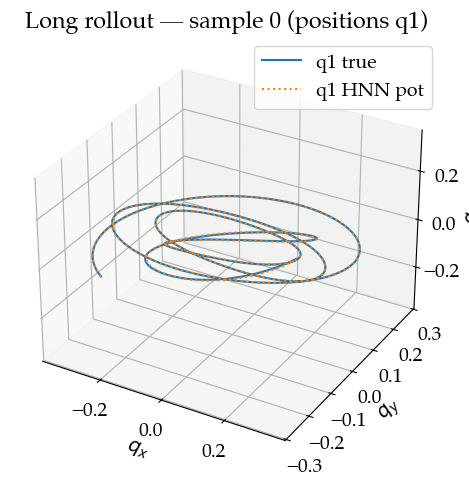

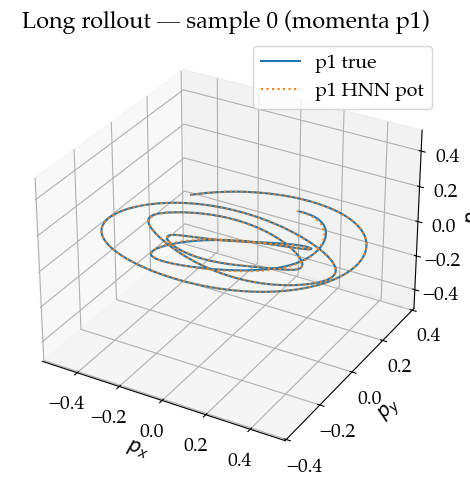

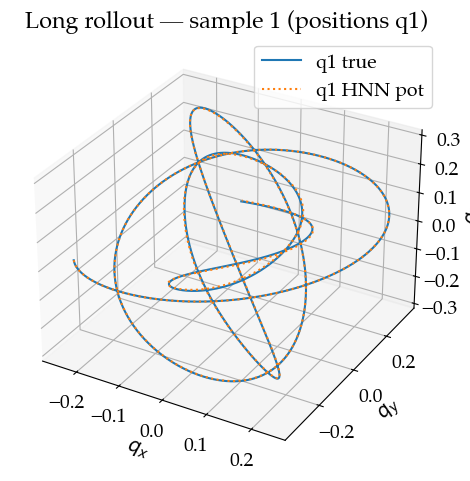

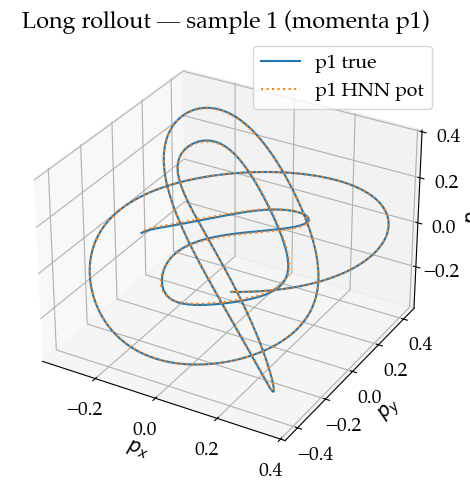

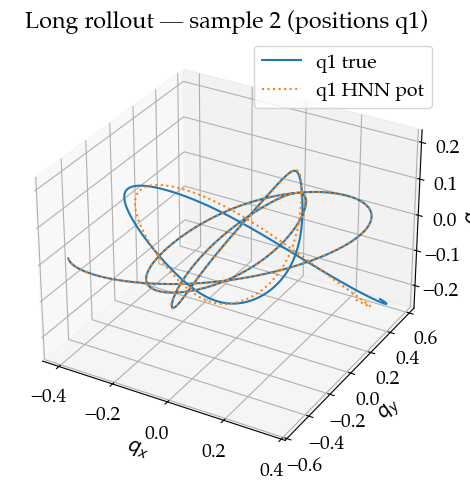

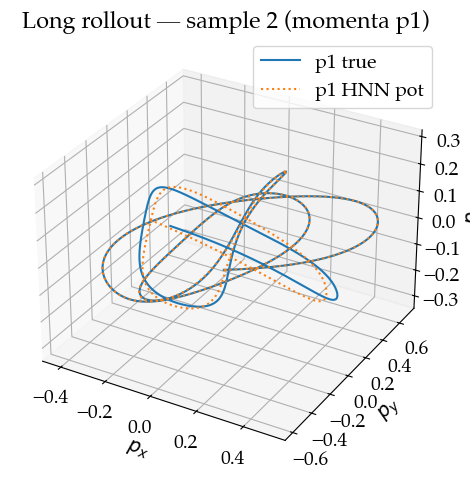

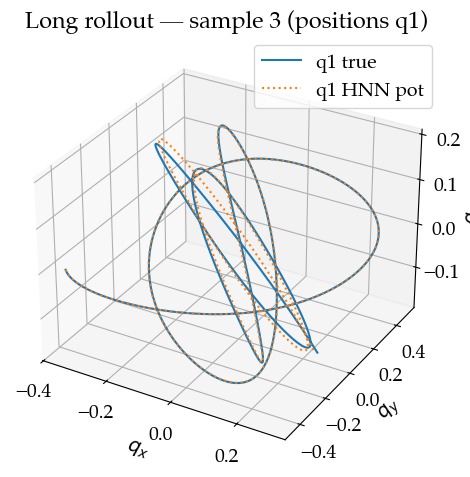

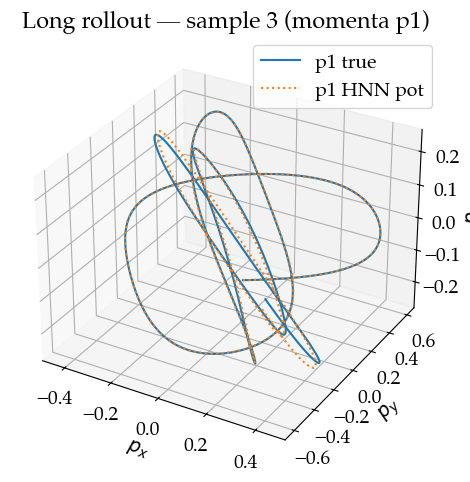

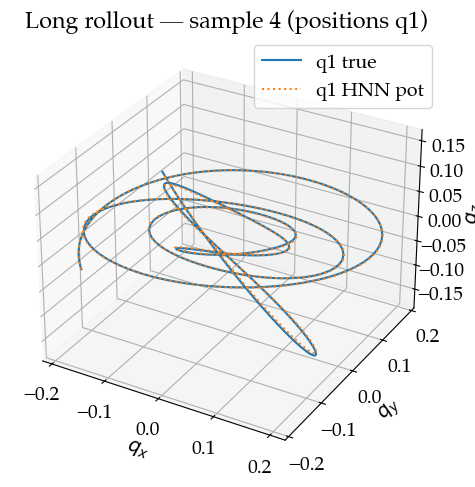

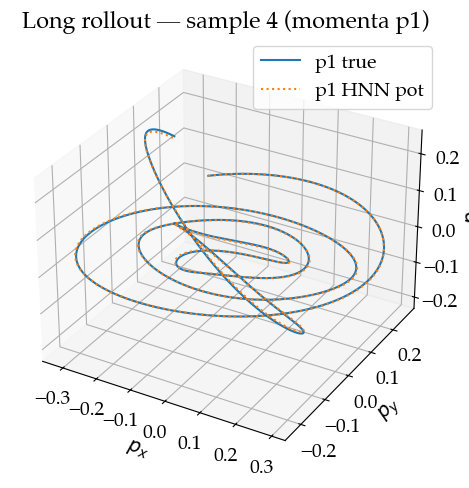

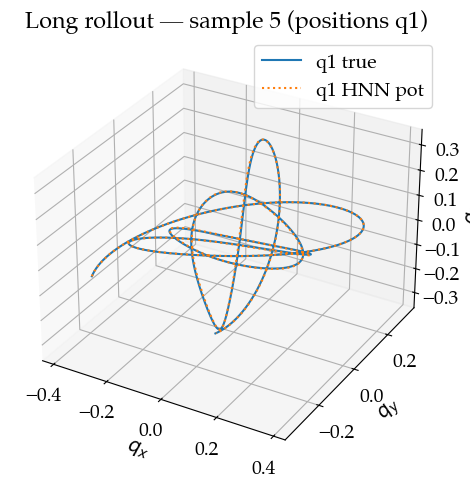

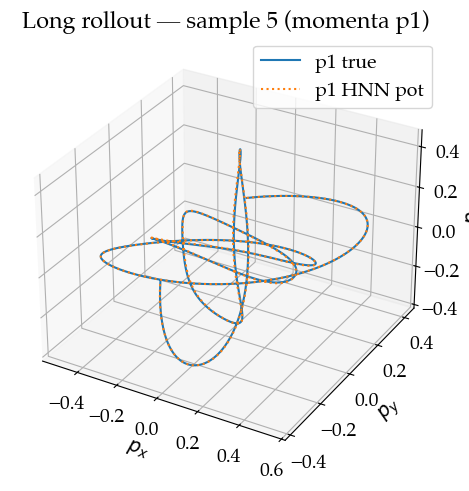

In [ ]:
plot_3d_trajectory(true_long, pred_hnn_pot_long)

In [ ]:
# from vector_fields import _pair_extention_direction

# def total_energy(y, params: Params):
#     qx0,qy0,qx1,qy1,qx2,qy2,px0,py0,px1,py1,px2,py2 = y[...,0], y[...,1], y[...,2], y[...,3], y[...,4], y[...,5], y[...,6], y[...,7], y[...,8], y[...,9], y[...,10], y[...,11]
    
#     r0 = jnp.array([qx0,qy0]);   r1 = jnp.array([qx1,qy1]);   r2 = jnp.array([qx2,qy2])

#     e01, _ = _pair_extention_direction(r0, r1, params.L01)
#     e02, _ = _pair_extention_direction(r0, r2, params.L02)
#     e12, _ = _pair_extention_direction(r1, r2, params.L12)

#     KE = 0.5*((px0**2 + py0**2)/params.m0 + (px1**2 + py1**2)/params.m1 + (px2**2 + py2**2)/params.m2)
#     PE = 0.5*(params.k0*e01**2 + params.k1*e12**2 + params.k2*e02**2)
#     return KE, PE

# def hnn_predicted_energy_2(model, y):
#     H = lambda y_: model(y_)                     # scalar, total energy
#     return jax.vmap(H)(y)

# def hnn_predicted_energy(model, y, params: Params):
#     KE, _ = total_energy(y, params)
#     PE = lambda y: model(y[:3])                     # scalar, total energy
#     return KE + jax.vmap(PE)(y)

# for i in range(B_show):
#     KE_true, PE_true = total_energy(true_long[i], system_params)
#     E_true = KE_true + PE_true
#     #E_hnn = hnn_predicted_energy(hnn_model_final, true_long[i], system_params) - hnn_model_final(jnp.array([system_params.L0, system_params.L0+system_params.L1, system_params.L0+system_params.L1+system_params.L2]))  # shift to zero baseline
#     E_hnn_2 = hnn_predicted_energy_2(hnn_model_final_2, true_long[i]) #- hnn_model_final_2(jnp.array([system_params.L0, system_params.L0+system_params.L1, system_params.L0+system_params.L1+system_params.L2, 0., 0., 0.]))  # shift to zero baseline

#     plt.figure(figsize=(7,4))
#     plt.plot(ts_long, E_true, label="True")
#     #plt.plot(ts_long, E_hnn, "--", label="HNN")
#     plt.plot(ts_long, E_hnn_2, label="HNN 2")
#     plt.xlabel("t"); plt.ylabel("Total Energy"); plt.title(f"Total Energy — sample {i}")
#     plt.legend(); plt.tight_layout(); plt.show()

In [ ]:
true_long.shape

(6, 20001, 12)

In [ ]:
plt.rcParams['font.size'] = 14
plt.rcParams['font.family'] = 'Palatino'
plt.rcParams['font.style'] = 'normal'

sintef_blue = '#003C65'
sintef_cyan = '#22A7E5'
sintef_green = '#A4C21F'
sintef_yellow = '#F7E918'
sintef_magenta = '#EC008C'

### Updated plotting function for comparing trajectories

In [ ]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib import animation
from pathlib import Path
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D projection


def animate_mass_spring_3d_jax(
    y,                         # jnp.ndarray or np.ndarray with shape [N, 6*M]
    y2=None,                   # optional second trajectory for comparison
    edges=None,                # list of (i,j) springs; default triangle (M=3) else chain
    save_path="mass_springs_3d.gif",
    fps=30,
    dpi=120,
    show_momenta=False,
    momentum_scale=0.2,
    mass_markersize=8,
    trail_len=None,            # e.g. 50 to show recent trajectory; None for no trails
    title=None,
    tight_limits=True,
    margin=0.1,                # padding fraction for axes
    frame_step=12,             # subsample frames
):

    # Bring data to host NumPy
    y_np = np.asarray(jax.device_get(y))
    assert y_np.ndim == 2, "y must be [N, 6*M]"
    N, D = y_np.shape
    assert D % 6 == 0, "State dimension must be divisible by 6 (qx,qy,qz,...,px,py,pz,...)"
    M = D // 6

    # Process second trajectory if provided
    y2_np = None
    if y2 is not None:
        y2_np = np.asarray(jax.device_get(y2))
        assert y2_np.shape == y_np.shape, "y2 must have same shape as y"

    # Subsample frames
    idx = np.arange(0, N, frame_step, dtype=int)
    y_np = y_np[idx]
    if y2_np is not None:
        y2_np = y2_np[idx]
    N = y_np.shape[0]

    # Unpack primary trajectory
    pos = y_np[:, : 3 * M].reshape(N, M, 3)        # [N, M, 3] -> (x,y,z)
    mom = y_np[:, 3 * M : 6 * M].reshape(N, M, 3)  # [N, M, 3]

    # Unpack second trajectory if present
    pos2 = None
    mom2 = None
    if y2_np is not None:
        pos2 = y2_np[:, : 3 * M].reshape(N, M, 3)
        mom2 = y2_np[:, 3 * M : 6 * M].reshape(N, M, 3)

    # Default spring topology
    if edges is None:
        edges = [(0, 1), (1, 2), (2, 0)] if M == 3 else [(i, i + 1) for i in range(M - 1)]

    # Axis limits (considering both trajectories)
    if tight_limits:
        all_pos = [pos]
        if pos2 is not None:
            all_pos.append(pos2)
        all_pos_concat = np.concatenate(all_pos, axis=0)  # [N_total, M, 3]

        xmin = all_pos_concat[:, :, 0].min()
        xmax = all_pos_concat[:, :, 0].max()
        ymin = all_pos_concat[:, :, 1].min()
        ymax = all_pos_concat[:, :, 1].max()
        zmin = all_pos_concat[:, :, 2].min()
        zmax = all_pos_concat[:, :, 2].max()

        dx = xmax - xmin
        dy = ymax - ymin
        dz = zmax - zmin

        pad_x = margin * (dx if dx > 0 else 1.0)
        pad_y = margin * (dy if dy > 0 else 1.0)
        pad_z = margin * (dz if dz > 0 else 1.0)

        xmin, xmax = xmin - pad_x, xmax + pad_x
        ymin, ymax = ymin - pad_y, ymax + pad_y
        zmin, zmax = zmin - pad_z, zmax + pad_z

    # Figure + 3D axes
    fig = plt.figure(figsize=(6, 6), dpi=dpi)
    ax = fig.add_subplot(111, projection="3d")
    if title:
        ax.set_title(title)

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")

    if tight_limits:
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_zlim(zmin, zmax)

    # Colors for masses (mass 1 gets different color)
    mass_colors = ['#1f77b4', '#ff7f0e', '#1f77b4']  # blue, orange, blue
    if M > 3:
        # simple extension if more masses: repeat colors
        mass_colors = (mass_colors * ((M + 2) // 3))[:M]

    # --- create artists for primary trajectory ---
    mass_scatters = []
    for i in range(M):
        scatter, = ax.plot(
            [], [], [], "s",
            ms=mass_markersize * 0.8,
            color=mass_colors[i],
            alpha=0.5,
            label="Unobserved mass (true)" if i == 1 and M == 3 else None,
            zorder=4,
        )
        mass_scatters.append(scatter)

    # spring_lines = [
    #     ax.plot([], [], [], "-", color="gray", lw=1.5, zorder=1)[0]
    #     for _ in edges
    # ]

    # trails
    trail_lines = None
    if trail_len and trail_len > 0:
        trail_lines = [
            ax.plot([], [], [], "--", alpha=0.4, color=mass_colors[m], lw=1)[0]
            for m in range(M)
        ]

    time_text = fig.text(0.02, 0.95, "", transform=fig.transFigure, va="top")


    # --- artists for second trajectory (if present) ---
    mass_scatters2 = None
    spring_lines2 = None
    trail_lines2 = None
    #mom_quivers2 = None

    if pos2 is not None:
        mass_scatters2 = []
        for i in range(M):
            scatter, = ax.plot(
                [], [], [], "o",
                ms=mass_markersize,
                color=mass_colors[i],
                label="Unobserved mass (predicted)" if i == 1 and M == 3 else None,
                zorder=5,
            )
            mass_scatters2.append(scatter)

        # spring_lines2 = [
        #     ax.plot([], [], [], "--", color="gray", lw=1.0, alpha=0.5, zorder=0)[0]
        #     for _ in edges
        # ]

        if trail_len and trail_len > 0:
            trail_lines2 = [
                ax.plot([], [], [], "-", alpha=0.6, color=mass_colors[m], lw=1)[0]
                for m in range(M)
            ]

    if M == 3:
        ax.legend(loc="upper right")

    # --- init function ---
    def init():

        for scatter in mass_scatters:
            scatter.set_data([], [])
            scatter.set_3d_properties([])

        # for ln in spring_lines:
        #     ln.set_data([], [])
        #     ln.set_3d_properties([])

        if trail_lines:
            for ln in trail_lines:
                ln.set_data([], [])
                ln.set_3d_properties([])

        if mass_scatters2:
            for scatter in mass_scatters2:
                scatter.set_data([], [])
                scatter.set_3d_properties([])

        # if spring_lines2:
        #     for ln in spring_lines2:
        #         ln.set_data([], [])
        #         ln.set_3d_properties([])

        if trail_lines2:
            for ln in trail_lines2:
                ln.set_data([], [])
                ln.set_3d_properties([])

        time_text.set_text("")

        artists = [*mass_scatters]#, *spring_lines]
        if trail_lines:
            artists.extend(trail_lines)
        if mass_scatters2:
            artists.extend(mass_scatters2)
        # if spring_lines2:
        #     artists.extend(spring_lines2)
        if trail_lines2:
            artists.extend(trail_lines2)
        artists.append(time_text)
        return artists

    # --- update function ---
    def update(frame):

        # primary trajectory masses
        for i, scatter in enumerate(mass_scatters):
            scatter.set_data([pos[frame, i, 0]], [pos[frame, i, 1]])
            scatter.set_3d_properties([pos[frame, i, 2]])

        # primary springs
        # for ln, (i, j) in zip(spring_lines, edges):
        #     ln.set_data(
        #         [pos[frame, i, 0], pos[frame, j, 0]],
        #         [pos[frame, i, 1], pos[frame, j, 1]],
        #     )
        #     ln.set_3d_properties(
        #         [pos[frame, i, 2], pos[frame, j, 2]]
        #     )

        # primary trails
        if trail_lines:
            start = max(0, frame - trail_len + 1)
            for m, ln in enumerate(trail_lines):
                ln.set_data(
                    pos[start:frame + 1, m, 0],
                    pos[start:frame + 1, m, 1],
                )
                ln.set_3d_properties(
                    pos[start:frame + 1, m, 2]
                )

        # second trajectory (if present)
        if mass_scatters2:
            for i, scatter in enumerate(mass_scatters2):
                scatter.set_data([pos2[frame, i, 0]], [pos2[frame, i, 1]])
                scatter.set_3d_properties([pos2[frame, i, 2]])

            # for ln, (i, j) in zip(spring_lines2, edges):
            #     ln.set_data(
            #         [pos2[frame, i, 0], pos2[frame, j, 0]],
            #         [pos2[frame, i, 1], pos2[frame, j, 1]],
            #     )
            #     ln.set_3d_properties(
            #         [pos2[frame, i, 2], pos2[frame, j, 2]]
            #     )

            if trail_lines2:
                start = max(0, frame - trail_len + 1)
                for m, ln in enumerate(trail_lines2):
                    ln.set_data(
                        pos2[start:frame + 1, m, 0],
                        pos2[start:frame + 1, m, 1],
                    )
                    ln.set_3d_properties(
                        pos2[start:frame + 1, m, 2]
                    )

        #time_text.set_text(f"frame {frame+1}/{N}")

        # If you want zoom effect by adjusting the axes:
        #-----------------------------------------------
        # current_pos_list = [pos[:frame+1, :, :]]  # Primary trajectory
        # if pos2 is not None:
        #     current_pos_list.append(pos2[:frame+1, :, :])  # Secondary trajectory

        # current_pos_list = jnp.concatenate(jnp.array(current_pos_list), axis=0)
        
        # x_min, x_max = current_pos_list[:, :, 0].min(), current_pos_list[:, :, 0].max()
        # y_min, y_max = current_pos_list[:, :, 1].min(), current_pos_list[:, :, 1].max()
        # z_min, z_max = current_pos_list[:, :, 2].min(), current_pos_list[:, :, 2].max()
        
        # margin = 0.5
        # ax.set_xlim3d(x_min - margin, x_max + margin)
        # ax.set_ylim3d(y_min - margin, y_max + margin)
        # ax.set_zlim3d(z_min - margin, z_max + margin)
        #-------------------------------------------------

        artists = [*mass_scatters]#, *spring_lines]
        if trail_lines:
            artists.extend(trail_lines)
        if mass_scatters2:
            artists.extend(mass_scatters2)
        # if spring_lines2:
        #     artists.extend(spring_lines2)
        if trail_lines2:
            artists.extend(trail_lines2)
        artists.append(time_text)

        return artists

    # NOTE: blitting is troublesome with 3D + quiver → use blit=False
    anim = animation.FuncAnimation(
        fig, update, init_func=init, frames=N, interval=1000 / fps, blit=False
    )

    # Save
    save_path = str(Path(save_path))
    ext = Path(save_path).suffix.lower()
    if ext == ".gif":
        try:
            writer = animation.PillowWriter(fps=fps)
        except Exception as e:
            plt.close(fig)
            raise RuntimeError(
                "Saving GIF requires Pillow. Install with `pip install pillow`."
            ) from e
        anim.save(save_path, writer=writer, dpi=dpi)
    elif ext == ".mp4":
        try:
            writer = animation.FFMpegWriter(fps=fps)
        except Exception as e:
            plt.close(fig)
            raise RuntimeError(
                "Saving MP4 requires ffmpeg available on PATH."
            ) from e
        anim.save(save_path, writer=writer, dpi=dpi)
    else:
        plt.close(fig)
        raise ValueError("save_path must end with .gif or .mp4")

    plt.close(fig)
    return save_path, anim


In [ ]:
# y_true, y_pred: shape (N, 6*M), canonical [q(3M), p(3M)]
path, anim = animate_mass_spring_3d_jax(
    true_long[5],
    y2=pred_hnn_pot_long[5],
    edges=[(0,1),(1,2),(2,0)],
    save_path="checkpoints/plummersoftening/eps_1-0/radius_1-0/relative_distances/2025-12-08/tbp_true_vs_hnn_potenergy_3d.mp4",
    show_momenta=False,
    trail_len=40,
    frame_step=16,
    title="",
)
print("Saved to:", path)


Saved to: checkpoints/plummersoftening/eps_1-0/radius_1-0/relative_distances/2025-12-08/tbp_true_vs_hnn_potenergy_3d.mp4


In [ ]:
def compare_and_plot_error(
    y_true, 
    y_pred, 
    ts, 
    y_pred_2=None,
    y_pred_3=None,
    y_pred_4=None,
    labels=None,
    title=None, 
    save_path=None
):
    """
    Plot position errors over time for observed and unobserved masses across multiple models.
    
    State layout: [qx0,qy0,qx1,qy1,qx2,qy2, px0,py0,px1,py1,px2,py2]
    - Mass 0,2: observed (indices 0,1,4,5 for positions)
    - Mass 1: unobserved (indices 2,3 for positions)
    
    Parameters
    ----------
    y_true : array [N_time, 12]
        Ground truth trajectory in canonical coordinates
    y_pred : array [N_time, 12]
        First predicted trajectory in canonical coordinates
    ts : array [N_time]
        Time points
    y_pred_2 : array [N_time, 12], optional
        Second predicted trajectory for comparison
    y_pred_3 : array [N_time, 12], optional
        Third predicted trajectory for comparison
    labels : list of str, optional
        Labels for each model. Default: ["Model 1", "Model 2", "Model 3"]
    title : str, optional
        Figure title
    save_path : str, optional
        Path to save figure
    
    Returns
    -------
    dict
        Dictionary with keys 'model_1', 'model_2', 'model_3' (as available),
        each containing {'error_unobserved': array, 'error_observed': array}
    """
    y_true = jnp.asarray(y_true)
    y_pred = jnp.asarray(y_pred)
    ts = jnp.asarray(ts)
    
    # Collect all predictions
    predictions = [y_pred]
    if y_pred_2 is not None:
        predictions.append(jnp.asarray(y_pred_2))
    if y_pred_3 is not None:
        predictions.append(jnp.asarray(y_pred_3))
    if y_pred_4 is not None:
        predictions.append(jnp.asarray(y_pred_4))
    
    # Default labels
    if labels is None:
        labels = ["Model 1", "Model 2", "Model 3", "Model 4"][:len(predictions)]
    
    # Colors for each model (colorblind-friendly palette)
    model_colors = [sintef_blue, sintef_cyan, sintef_green, sintef_yellow]
    
    # Line styles: solid for unobserved, dashed for observed
    linestyle_unobserved = '-'
    linestyle_observed = '--'
    
    # Compute errors for all predictions
    results = {}
    q_true = y_true[:, :6].reshape(-1, 3, 2)  # [N, 3, 2] -> (time, mass, xy)
    
    for idx, y_pred_i in enumerate(predictions):
        q_pred = y_pred_i[:, :6].reshape(-1, 3, 2)
        
        # Compute L2 distance for each mass at each timestep
        mass_errors = jnp.linalg.norm(q_true - q_pred, axis=-1)
        
        # Mass 1 error (unobserved)
        error_unobserved = mass_errors[:, 1]
        
        # Mass 0 and 2 error (observed), averaged
        error_observed = (mass_errors[:, 0] + mass_errors[:, 2]) / 2.0
        
        results[f'model_{idx+1}'] = {
            'error_unobserved': error_unobserved,
            'error_observed': error_observed
        }
    
    # Create figure
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Plot errors for each model
    for idx, (model_key, errors) in enumerate(results.items()):
        color = model_colors[idx]
        label = labels[idx]
        
        # Unobserved mass (solid line)
        ax.plot(ts, errors['error_unobserved'], 
                color=color, 
                linestyle=linestyle_unobserved,
                lw=2.5, 
                label=f'{label} - Mass 1 (unobserved)',
                alpha=0.9)
        
        # Observed masses (dashed line)
        ax.plot(ts, errors['error_observed'], 
                color=color, 
                linestyle=linestyle_observed,
                lw=2.0, 
                label=f'{label} - Mass 0&2 (observed)',
                alpha=0.7)
    
    ax.set_xlabel('Time')
    ax.set_ylabel('Position Error (L2 norm)')
    ax.set_title(title if title else 'Model Comparison: Prediction Error Over Time', 
                 fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle=':')
    #ax.set_yscale('log')
    ax.legend(loc='upper left', fontsize=10, framealpha=0.95)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Figure saved to: {save_path}")
    
    plt.show()
    
    # Print summary statistics for all models
    print("\n" + "="*70)
    print("MODEL COMPARISON - ERROR STATISTICS")
    print("="*70)
    
    for idx, (model_key, errors) in enumerate(results.items()):
        label = labels[idx]
        print(f"\n{label}:")
        print(f"  Unobserved mass (Mass 1):")
        print(f"    Mean error:  {jnp.mean(errors['error_unobserved']):.6f}")
        print(f"    Max error:   {jnp.max(errors['error_unobserved']):.6f}")
        print(f"    Final error: {errors['error_unobserved'][-1]:.6f}")
        print(f"  Observed masses (Mass 0 & 2, averaged):")
        print(f"    Mean error:  {jnp.mean(errors['error_observed']):.6f}")
        print(f"    Max error:   {jnp.max(errors['error_observed']):.6f}")
        print(f"    Final error: {errors['error_observed'][-1]:.6f}")
    
    print("="*70 + "\n")
    
    return results



Figure saved to: checkpoints/spring_constant_0-05/error_true_vs_hnn_tot_vs_hnn_pot_vs_node.png


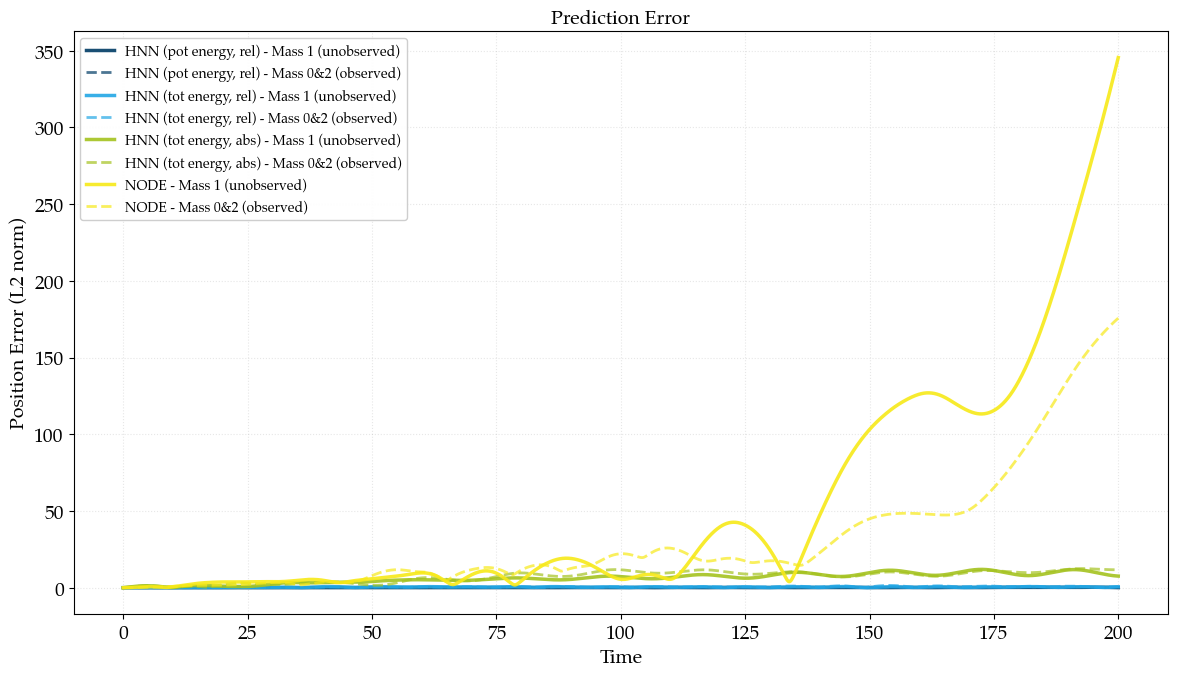


MODEL COMPARISON - ERROR STATISTICS

HNN (pot energy, rel):
  Unobserved mass (Mass 1):
    Mean error:  0.077362
    Max error:   0.288144
    Final error: 0.051898
  Observed masses (Mass 0 & 2, averaged):
    Mean error:  0.103837
    Max error:   0.244377
    Final error: 0.121124

HNN (tot energy, rel):
  Unobserved mass (Mass 1):
    Mean error:  0.380257
    Max error:   0.724456
    Final error: 0.549887
  Observed masses (Mass 0 & 2, averaged):
    Mean error:  0.520758
    Max error:   1.492596
    Final error: 0.756514

HNN (tot energy, abs):
  Unobserved mass (Mass 1):
    Mean error:  6.284690
    Max error:   11.925887
    Final error: 7.553387
  Observed masses (Mass 0 & 2, averaged):
    Mean error:  7.191546
    Max error:   12.443530
    Final error: 11.652261

NODE:
  Unobserved mass (Mass 1):
    Mean error:  52.354858
    Max error:   345.523041
    Final error: 345.523041
  Observed masses (Mass 0 & 2, averaged):
    Mean error:  30.729862
    Max error:   175.70

In [ ]:
results = compare_and_plot_error(
    y_true=true_long[3],
    y_pred=pred_hnn_pot_long[3],
    y_pred_2=pred_hnn_tot_long[3],
    y_pred_3=pred_hnn_tot_abs_long[3],
    y_pred_4=pred_node_long[3],
    ts=ts_long,
    labels=["HNN (pot energy, rel)", "HNN (tot energy, rel)", "HNN (tot energy, abs)", "NODE"],
    title="Prediction Error",
    save_path="checkpoints/spring_constant_0-05/error_true_vs_hnn_tot_vs_hnn_pot_vs_node2.png"
)
    

In [ ]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib import animation
from pathlib import Path
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  # needed for 3D projection


def animate_mass_spring_3d_grid_jax(
    y_true,                      # [N, 6*M] true trajectory
    y_pred1=None,                # [N, 6*M] or None
    y_pred2=None,
    y_pred3=None,
    y_pred4=None,
    edges=None,                  # list of (i,j) springs; default triangle/chain
    labels=None,                 # list of labels for each prediction panel
    save_path="mass_springs_3d_grid.mp4",
    fps=30,
    dpi=120,
    mass_markersize=8,
    trail_len=None,              # e.g. 50; None for no trails
    title=None,
    tight_limits=True,
    margin=0.1,                  # padding fraction for axes
    frame_step=8,                # subsample frames
):
    """
    Animate a 3D mass–spring system, comparing multiple predicted trajectories
    against a common true trajectory, in a grid of 3D subplots.

    State layout per frame: [qx0,qy0,qz0, ..., px0,py0,pz0, ...]
    → shape [N, 6*M].

    Parameters
    ----------
    y_true : [N, 6*M]
        JAX or NumPy array of true system states over time.
    y_pred1..4 : [N, 6*M] or None
        Predicted trajectories to compare (each panel: true vs one prediction).
    edges : list[(int,int)] or None
        Spring topology. Defaults:
          - M==3: triangle [(0,1),(1,2),(2,0)]
          - else: chain [(0,1),(1,2),...,(M-2,M-1)]
    labels : list[str] or None
        Labels for panels (e.g., ["HNN", "NODE", "Baseline"]). If None, auto.
    save_path : str
        Output file (.gif or .mp4).
    """
    # Collect predictions into a list
    preds_raw = [y_pred1, y_pred2, y_pred3, y_pred4]
    preds_raw = [p for p in preds_raw if p is not None]
    K = len(preds_raw)
    if K == 0:
        raise ValueError("At least one prediction (y_pred1..y_pred4) must be provided.")
    if K > 4:
        raise ValueError("At most 4 predictions supported.")

    # Bring true data to host NumPy
    y_true_np = np.asarray(jax.device_get(y_true))
    assert y_true_np.ndim == 2, "y_true must be [N, 6*M]"
    N, D = y_true_np.shape
    assert D % 6 == 0, "State dim must be divisible by 6 (qx,qy,qz,...,px,py,pz,...)"
    M = D // 6

    # Bring preds to NumPy and validate shapes
    preds_np = []
    for p in preds_raw:
        p_np = np.asarray(jax.device_get(p))
        assert p_np.shape == y_true_np.shape, "All predictions must have same shape as y_true"
        preds_np.append(p_np)

    # Subsample frames
    idx = np.arange(0, N, frame_step, dtype=int)
    y_true_np = y_true_np[idx]
    preds_np = [p[idx] for p in preds_np]
    N = y_true_np.shape[0]

    # Unpack true trajectory
    pos_true = y_true_np[:, : 3 * M].reshape(N, M, 3)   # [N, M, 3]

    # Unpack predictions
    pos_preds = [p[:, : 3 * M].reshape(N, M, 3) for p in preds_np]

    # Default edges
    if edges is None:
        edges = [(0, 1), (1, 2), (2, 0)] if M == 3 else [(i, i + 1) for i in range(M - 1)]

    # Axis limits over true + all preds
    if tight_limits:
        all_pos = [pos_true] + pos_preds
        all_pos_concat = np.concatenate(all_pos, axis=0)  # [N_total, M, 3]

        xmin = all_pos_concat[:, :, 0].min()
        xmax = all_pos_concat[:, :, 0].max()
        ymin = all_pos_concat[:, :, 1].min()
        ymax = all_pos_concat[:, :, 1].max()
        zmin = all_pos_concat[:, :, 2].min()
        zmax = all_pos_concat[:, :, 2].max()

        dx = xmax - xmin
        dy = ymax - ymin
        dz = zmax - zmin

        pad_x = margin * (dx if dx > 0 else 1.0)
        pad_y = margin * (dy if dy > 0 else 1.0)
        pad_z = margin * (dz if dz > 0 else 1.0)

        xmin, xmax = xmin - pad_x, xmax + pad_x
        ymin, ymax = ymin - pad_y, ymax + pad_y
        zmin, zmax = zmin - pad_z, zmax + pad_z

    # Panel labels
    if labels is None:
        labels = [f"Model {i+1}" for i in range(K)]
    else:
        assert len(labels) == K, "labels must have same length as number of predictions"

    # Layout: up to 2x2 grid
    if K <= 2:
        nrows, ncols = 1, K
    elif K == 3:
        nrows, ncols = 1, 3  # last panel empty
    else:  # K == 4
        nrows, ncols = 1, 4

    # Colors per mass
    mass_colors = ['#1f77b4', '#ff7f0e', '#1f77b4']  # blue, orange, blue
    if M > 3:
        mass_colors = (mass_colors * ((M + 2) // 3))[:M]

    # # Figure + axes
    # fig = plt.figure(figsize=(6 * ncols, 6 * nrows), dpi=dpi)
    # axes = []

    # panel_indices = []  # mapping from subplot index -> prediction index or None

    # pred_idx = 0
    # for r in range(nrows):
    #     for c in range(ncols):
    #         ax_idx = r * ncols + c
    #         if ax_idx < K:
    #             # Active panel with a prediction to show
    #             ax = fig.add_subplot(nrows, ncols, ax_idx + 1, projection="3d")
    #             axes.append(ax)
    #             panel_indices.append(pred_idx)
    #             pred_idx += 1
    #         else:
    #             # Empty panel if K=3
    #             ax = fig.add_subplot(nrows, ncols, ax_idx + 1, projection="3d")
    #             ax.set_axis_off()
    #             axes.append(ax)
    #             panel_indices.append(None)
    # --- Figure + axes (tight layout using GridSpec) ---
    fig = plt.figure(figsize=(5 * ncols, 5 * nrows), dpi=dpi)

    # Create a GridSpec with small spacing
    gs = fig.add_gridspec(
        nrows, ncols,
        wspace=0.02,   # horizontal spacing between panels
        hspace=0.02    # vertical spacing between panels
    )

    axes = []
    panel_indices = []
    pred_idx = 0

    for r in range(nrows):
        for c in range(ncols):
            ax_idx = r * ncols + c

            # Attach subplot to correct grid cell
            ax = fig.add_subplot(gs[r, c], projection="3d")

            if ax_idx < K:
                axes.append(ax)
                panel_indices.append(pred_idx)
                pred_idx += 1
            else:
                ax.set_axis_off()   # Hide unused panel (when K=3)
                axes.append(ax)
                panel_indices.append(None)

    # Apply overall figure tightening
    fig.tight_layout(pad=0.2, w_pad=0.05, h_pad=0.05)

    if title:
        fig.suptitle(title)

    # Set common limits and labels
    for ax, pidx in zip(axes, panel_indices):
        if pidx is None:
            continue
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_zlabel("z")
        if tight_limits:
            # ax.set_xlim(xmin, xmax)
            # ax.set_ylim(ymin, ymax)
            # ax.set_zlim(zmin, zmax)
            ax.set_xlim(-2.5, 2.5)
            ax.set_ylim(-2, 2)
            ax.set_zlim(-2, 2)
        ax.set_title(labels[pidx])
        # equal-ish aspect
        try:
            ax.set_box_aspect([1, 1, 1])
        except Exception:
            pass

    # --- Create artists for each active panel ---
    # For each panel: mass_scatters_true[k][m], mass_scatters_pred[k][m], spring_lines_true/pred
    panels = []  # list of dicts per panel

    for ax, pidx in zip(axes, panel_indices):
        if pidx is None:
            panels.append(None)
            continue

        # artists
        mass_scatters_true = []
        mass_scatters_pred = []

        for i in range(M):
            # true masses: solid circles
            sc_true, = ax.plot(
                [], [], [], "s",
                ms=mass_markersize * 0.8,
                color=mass_colors[i],
                alpha=0.6,
                zorder=4,
                label="true" if i == 0 else None,
            )
            mass_scatters_true.append(sc_true)

            # predicted masses: semi-transparent squares
            sc_pred, = ax.plot(
                [], [], [], "o",
                ms=mass_markersize,
                color=mass_colors[i],
                zorder=5,
                label="pred" if i == 0 else None,
            )
            mass_scatters_pred.append(sc_pred)

        spring_true = [
            ax.plot([], [], [], "--", color="gray", lw=1.0, alpha=0.6, zorder=0)[0]
            for _ in edges
        ]
        spring_pred = [
            ax.plot([], [], [], "-", color="gray", lw=1.5, zorder=1)[0]
            for _ in edges
        ]

        # trails
        trail_true = None
        trail_pred = None
        if trail_len and trail_len > 0:
            trail_true = [
                ax.plot([], [], [], "--", alpha=0.5, color=mass_colors[m], lw=1)[0]
                for m in range(M)
            ]
            trail_pred = [
                ax.plot([], [], [], "-", alpha=0.7, color=mass_colors[m], lw=1)[0]
                for m in range(M)
            ]

        panels.append(
            dict(
                ax=ax,
                pidx=pidx,
                mass_scatters_true=mass_scatters_true,
                mass_scatters_pred=mass_scatters_pred,
                spring_true=spring_true,
                spring_pred=spring_pred,
                trail_true=trail_true,
                trail_pred=trail_pred,
            )
        )

    # One time text for the whole figure
    time_text = fig.text(0.01, 0.01, "", va="bottom", ha="left")

    # --- init function ---
    def init():
        for panel in panels:
            if panel is None:
                continue
            for sc in panel["mass_scatters_true"]:
                sc.set_data([], [])
                sc.set_3d_properties([])
            for sc in panel["mass_scatters_pred"]:
                sc.set_data([], [])
                sc.set_3d_properties([])
            for ln in panel["spring_true"]:
                ln.set_data([], [])
                ln.set_3d_properties([])
            for ln in panel["spring_pred"]:
                ln.set_data([], [])
                ln.set_3d_properties([])
            if panel["trail_true"]:
                for ln in panel["trail_true"]:
                    ln.set_data([], [])
                    ln.set_3d_properties([])
            if panel["trail_pred"]:
                for ln in panel["trail_pred"]:
                    ln.set_data([], [])
                    ln.set_3d_properties([])

        time_text.set_text("")
        return [time_text]

    # --- update function ---
    def update(frame):
        # true positions at this frame
        pt = pos_true[frame]  # [M, 3]

        for panel in panels:
            if panel is None:
                continue

            pidx = panel["pidx"]
            pp = pos_preds[pidx][frame]  # [M, 3]

            # masses
            for i, sc in enumerate(panel["mass_scatters_true"]):
                sc.set_data([pt[i, 0]], [pt[i, 1]])
                sc.set_3d_properties([pt[i, 2]])

            for i, sc in enumerate(panel["mass_scatters_pred"]):
                sc.set_data([pp[i, 0]], [pp[i, 1]])
                sc.set_3d_properties([pp[i, 2]])

            # springs
            for ln, (i, j) in zip(panel["spring_true"], edges):
                ln.set_data([pt[i, 0], pt[j, 0]], [pt[i, 1], pt[j, 1]])
                ln.set_3d_properties([pt[i, 2], pt[j, 2]])

            for ln, (i, j) in zip(panel["spring_pred"], edges):
                ln.set_data([pp[i, 0], pp[j, 0]], [pp[i, 1], pp[j, 1]])
                ln.set_3d_properties([pp[i, 2], pp[j, 2]])

            # trails
            if panel["trail_true"] or panel["trail_pred"]:
                start = max(0, frame - (trail_len or 0) + 1)
                if start < 0:
                    start = 0

            if panel["trail_true"]:
                for m, ln in enumerate(panel["trail_true"]):
                    ln.set_data(
                        pos_true[start:frame + 1, m, 0],
                        pos_true[start:frame + 1, m, 1],
                    )
                    ln.set_3d_properties(
                        pos_true[start:frame + 1, m, 2]
                    )

            if panel["trail_pred"]:
                pos_p_all = pos_preds[pidx]
                for m, ln in enumerate(panel["trail_pred"]):
                    ln.set_data(
                        pos_p_all[start:frame + 1, m, 0],
                        pos_p_all[start:frame + 1, m, 1],
                    )
                    ln.set_3d_properties(
                        pos_p_all[start:frame + 1, m, 2]
                    )

        time_text.set_text(f"frame {frame+1}/{N}")
        return [time_text]

    # 3D + multiple axes → blit=False is safer
    anim = animation.FuncAnimation(
        fig, update, init_func=init, frames=N, interval=1000 / fps, blit=False
    )

    # Save
    save_path = str(Path(save_path))
    ext = Path(save_path).suffix.lower()
    if ext == ".gif":
        try:
            writer = animation.PillowWriter(fps=fps)
        except Exception as e:
            plt.close(fig)
            raise RuntimeError("Saving GIF requires Pillow.") from e
        anim.save(save_path, writer=writer, dpi=dpi)
    elif ext == ".mp4":
        try:
            writer = animation.FFMpegWriter(fps=fps)
        except Exception as e:
            plt.close(fig)
            raise RuntimeError("Saving MP4 requires ffmpeg on PATH.") from e
        anim.save(save_path, writer=writer, dpi=dpi)
    else:
        plt.close(fig)
        raise ValueError("save_path must end with .gif or .mp4")

    plt.close(fig)
    return save_path, anim


In [ ]:
path, anim = animate_mass_spring_3d_grid_jax(
    y_true=true_long[2],
    #y_pred1=pred_node_long[2],
    #y_pred2=pred_hnn_tot_abs_long[2],
    #y_pred2=pred_hnn_tot_long[2],
    y_pred2=pred_hnn_pot_long[2],
    edges=[(0,1),(1,2),(2,0)],
    labels=["HNN (pot, abs)"],
    save_path="checkpoints/repulsive/compare_model_3d_grid3.mp4",
    trail_len=40,
    frame_step=10,
    title="",
)
print("Saved to:", path)


/var/folders/63/lsr6bh597y9gd6cc0mp34_jh0000gn/T/ipykernel_8579/3875650768.py:185: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(pad=0.2, w_pad=0.05, h_pad=0.05)


Saved to: checkpoints/repulsive/compare_model_3d_grid3.mp4
